# Two-level Lorenz-96 — model, simulation, and observation design

The two-level Lorenz-96 system (Wilks 2005, Arnold et al. 2013) is
the canonical **sub-grid** test problem for data assimilation. Each
slow variable $X_k$ couples to $J$ fast variables $Y_{j,k}$ that
evolve on a much shorter time-scale and at a much smaller amplitude.
The slow scale represents resolved dynamics; the fast scale, the
turbulent sub-grid processes that operational models cannot afford
to resolve.

Equations (Wilks 2005):

$$
\dot{X}_k = X_{k-1}(X_{k+1} - X_{k-2}) - X_k + F
          - \frac{hc}{b}\sum_{j=0}^{J-1} Y_{j,k},
$$

$$
\dot{Y}_{j,k} = -cb\, Y_{j+1,k}(Y_{j+2,k} - Y_{j-1,k})
              - c\, Y_{j,k} + \frac{hc}{b}\, X_k.
$$

The fast variables live on a single $JK$-long periodic ring; each
slow $X_k$ couples to a contiguous block of $J$ fast neighbours via
a mean back-reaction term. With $h = 1$, $c = 10$, $b = 10$,
$F = 20$ the system is fully chaotic in both regimes — the fast
scale is ten times faster and ten times smaller in amplitude than
the slow one.

Why this matters for DA:

- The fast variables are **dynamically coupled** to the slow ones
  but **not directly observed** in our setup. Their state must be
  inferred entirely through the coupling.
- A perfect-model 4DVar over the full state should recover the
  slow variables well; the fast variables are harder, and may even
  degrade under aggressive slow-fitting (a classic "imbalance"
  failure mode).

This notebook walks through the dynamics, simulation, observation
design, and sanity checks. The benchmark itself —
[`12_lorenz96_2l_benchmark`](12_lorenz96_2l_benchmark.ipynb) — runs
the seven `AnalysisStep` methods on the resulting problem.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from assimilation import Lorenz96TwoLevelForward, generate_l96_2l_problem

## 1. Decisions

| Parameter | Value | Rationale |
|---|---:|---|
| $K$ | 8 | Slow grid points. Smaller than L96-1L's 40 to keep the joint $(X, Y)$ state tractable. |
| $J$ | 8 | Fast variables per slow. Canonical Wilks 2005 uses $J = 32$; we scale down for speed. |
| $D$ | $K + JK = 72$ | Total flat state dimension. |
| $F$ | 20.0 | Strongly chaotic regime. $F = 10$ is weakly chaotic. |
| $h$ | 1.0 | Slow $\leftrightarrow$ fast coupling. |
| $c$ | 10.0 | Fast/slow time-scale ratio. |
| $b$ | 10.0 | Slow/fast amplitude ratio. |
| $dt$ | 0.005 | Half of L96-1L's $dt$. The fast scale is 10× faster so RK4 stability needs a smaller step. |
| $T$ | 40 | 41-step window (~$0.2$ physical time units). Long enough for fast dynamics to act, short enough for 4DVar's inner solve to stay tractable. |
| $\sigma_o$ | 0.5 | Obs noise std. Slow magnitudes are ~ ±10, so $\sigma_o = 0.5$ is a ~5% noise level. |

## 2. Simulate a long trajectory

Burn-in 2000 steps, then save 500 to inspect the spatial-temporal
structure of both regimes. The fast variables are much smaller and
faster — note the different colour scales.

In [2]:
fwd_long = Lorenz96TwoLevelForward(K=8, J=8, F=20.0, h=1.0, c=10.0, b=10.0, dt=0.005)
key = jax.random.PRNGKey(0)
x0 = jnp.concatenate(
    [20.0 * jnp.ones(8), jnp.zeros(64)]
) + 0.05 * jax.random.normal(key, (72,))


def _scan(state, _):
    new = fwd_long.step(state, fwd_long.dt)
    return new, new


state, _ = jax.lax.scan(_scan, x0, None, length=2000)
_, traj_long = jax.lax.scan(_scan, state, None, length=500)
print(f"long trajectory: {traj_long.shape}")
slow = traj_long[:, :8]
fast = traj_long[:, 8:]
print(f"slow range: [{float(slow.min()):.2f}, {float(slow.max()):.2f}]")
print(f"fast range: [{float(fast.min()):.2f}, {float(fast.max()):.2f}]")
print(f"slow std:   {float(slow.std()):.2f}")
print(f"fast std:   {float(fast.std()):.2f}")
print(f"amplitude ratio slow/fast: {float(slow.std() / fast.std()):.1f}  (theory: b = 10)")

long trajectory: (500, 72)
slow range: [-13.71, 19.36]


fast range: [-1.05, 1.69]
slow std:   6.20
fast std:   0.34
amplitude ratio slow/fast: 18.2  (theory: b = 10)


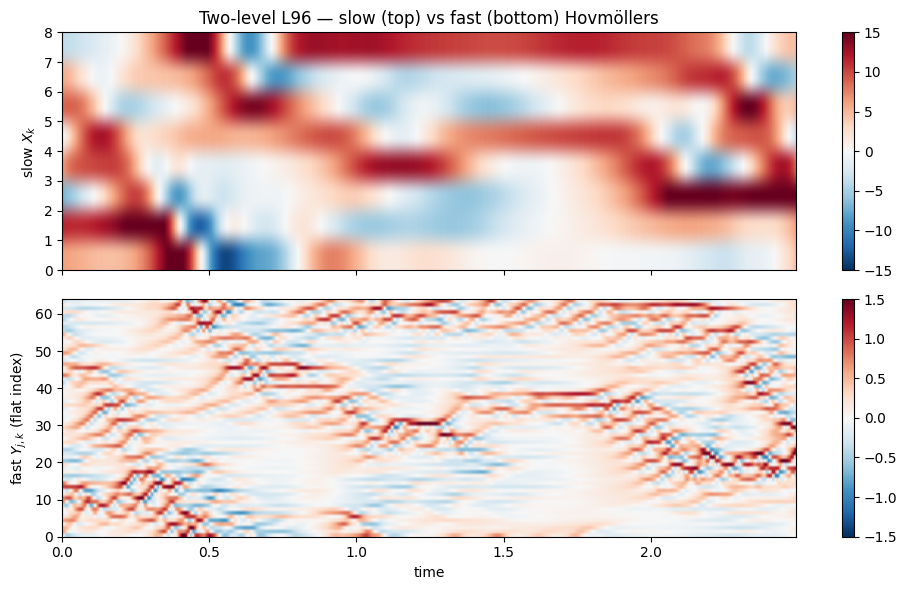

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = jnp.arange(500) * 0.005
extent_slow = (0, float(t[-1]), 0, 8)
extent_fast = (0, float(t[-1]), 0, 64)
im0 = axs[0].imshow(slow.T, aspect="auto", cmap="RdBu_r", origin="lower",
                   extent=extent_slow, vmin=-15, vmax=15)
axs[0].set_ylabel("slow $X_k$")
axs[0].set_title("Two-level L96 — slow (top) vs fast (bottom) Hovmöllers")
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(fast.T, aspect="auto", cmap="RdBu_r", origin="lower",
                   extent=extent_fast, vmin=-1.5, vmax=1.5)
axs[1].set_ylabel("fast $Y_{j,k}$ (flat index)")
axs[1].set_xlabel("time")
fig.colorbar(im1, ax=axs[1])
fig.tight_layout()
plt.show()

The slow band shows the L96-style travelling waves on a $K=8$ ring.
The fast band shows the much-faster oscillations on the $JK=64$
ring; the eight contiguous blocks of $J=8$ fast variables share
their coupling source ($X_k$) and so move together.

## 3. Observation design

We observe **only the slow $X_k$**, sparsely:

- every `obs_every_space`-th slow grid point (default 2 → 4 of 8)
- every `obs_every_time`-th step (default 4 → 11 of 41)

The fast block receives **no direct observations**. The benchmark
question is: given this slow-only, sparse-in-time signal, how well
can each method recover the full $(X, Y)$ state?

Total: $4 \times 11 = 44$ scalar obs constraining $41 \times 72 = 2952$
state entries.

In [4]:
prob = generate_l96_2l_problem(key=jax.random.PRNGKey(0))
print(f"K={prob.K}, J={prob.J}, D={prob.D}, T+1={prob.T_plus_1}")
print(f"obs coverage: {int(prob.mask.sum())} / {prob.mask.size} = "
      f"{prob.mask.sum() / prob.mask.size:.1%}")
print(f"obs *of slow block*: {int(prob.mask[:, :prob.K].sum())} / "
      f"{prob.mask[:, :prob.K].size}")
print(f"obs *of fast block*: {int(prob.mask[:, prob.K:].sum())} / "
      f"{prob.mask[:, prob.K:].size}  (none, by design)")

K=8, J=8, D=72, T+1=41
obs coverage: 44 / 2952 = 1.5%
obs *of slow block*: 44 / 328


obs *of fast block*: 0 / 2624  (none, by design)


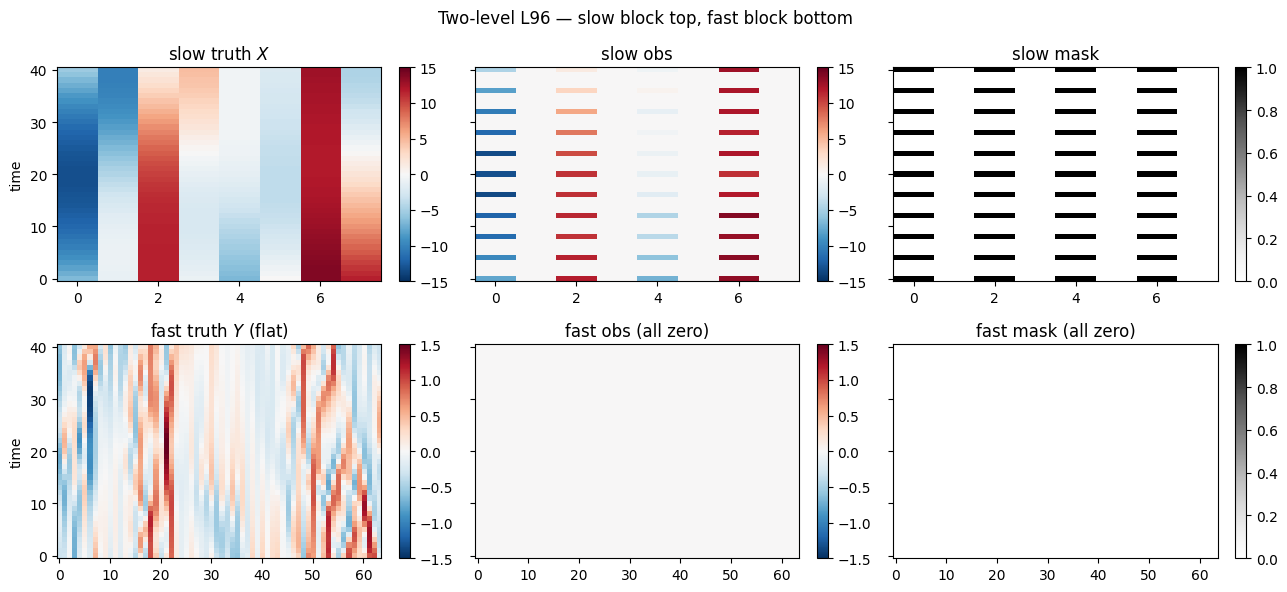

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6), sharey="row")
panels = [
    (prob.truth[:, :prob.K], "slow truth $X$", "RdBu_r", -15, 15),
    (prob.obs[:, :prob.K], "slow obs", "RdBu_r", -15, 15),
    (prob.mask[:, :prob.K], "slow mask", "Greys", 0, 1),
    (prob.truth[:, prob.K:], "fast truth $Y$ (flat)", "RdBu_r", -1.5, 1.5),
    (prob.obs[:, prob.K:], "fast obs (all zero)", "RdBu_r", -1.5, 1.5),
    (prob.mask[:, prob.K:], "fast mask (all zero)", "Greys", 0, 1),
]
for ax, (field, title, cmap, vmin, vmax) in zip(axs.ravel(), panels, strict=False):
    im = ax.imshow(field, aspect="auto", cmap=cmap, origin="lower",
                   vmin=vmin, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
axs[0, 0].set_ylabel("time")
axs[1, 0].set_ylabel("time")
fig.suptitle("Two-level L96 — slow block top, fast block bottom")
fig.tight_layout()
plt.show()

## 4. The prior floor and what it implies

With diagonal $B$ and a zero prior, the floor RMSE on each block is
its truth RMS. The slow block is ~20× the fast block in magnitude.

In [6]:
slow_rms = float(jnp.sqrt(jnp.mean(prob.truth[:, :prob.K] ** 2)))
fast_rms = float(jnp.sqrt(jnp.mean(prob.truth[:, prob.K:] ** 2)))
total_rms = float(jnp.sqrt(jnp.mean(prob.truth**2)))
print(f"slow  prior-floor RMSE: {slow_rms:.3f}")
print(f"fast  prior-floor RMSE: {fast_rms:.3f}")
print(f"total prior-floor RMSE: {total_rms:.3f}")

slow  prior-floor RMSE: 7.575
fast  prior-floor RMSE: 0.390
total prior-floor RMSE: 2.552


Two things to watch for in the benchmark:

1. **Slow recovery.** Sparse-time observations of every other slow
   grid point should let dynamics-aware 4DVar reconstruct the
   intermediate slow values via the chaotic propagation. A factor-2
   to factor-5 RMSE improvement over the prior is the expected win.
2. **Fast recovery.** Since the fast variables are *unobserved*,
   the only way to constrain them is through the slow-fast
   coupling. Strong-constraint 4DVar may actually **degrade** the
   fast RMSE below the prior floor — slow-fitting can drive the
   optimiser to fast values that minimise slow residual but
   diverge from the true fast state ("imbalance" failure mode).
   Weak-4DVar's model-error allowance softens this; amortized
   methods can leverage learned fast-state structure.

## 5. Forward roundtrip sanity check

In [7]:
fwd = Lorenz96TwoLevelForward(K=prob.K, J=prob.J, F=prob.F, h=prob.h,
                              c=prob.c, b=prob.b, dt=prob.dt)


def step(s, _):
    new = fwd.step(s, fwd.dt)
    return new, new


_, traj_rt = jax.lax.scan(step, prob.truth[0], None, length=prob.T)
truth_rt = jnp.concatenate([prob.truth[0][None, :], traj_rt], axis=0)
print(f"roundtrip max abs error: {float(jnp.max(jnp.abs(truth_rt - prob.truth))):.2e}")
print("(Zero — the truth was simulated with the same forward.)")

roundtrip max abs error: 0.00e+00
(Zero — the truth was simulated with the same forward.)


## 6. Next

Everything's set up. Continue to
[`12_lorenz96_2l_benchmark`](12_lorenz96_2l_benchmark.ipynb) to see
how each of the seven `AnalysisStep` methods recovers the slow
variables — and what happens to the fast ones under each.